In [1]:
%load_ext autoreload
%autoreload 2
import json
import os
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo
import pandas as pd


from src.api_call import headers, load_assets_from_json
import __main__
from src.temp_pre import HouseDataLoader, TwinPredictor, Seq2SeqDigitalTwin
setattr(__main__, "Seq2SeqDigitalTwin", Seq2SeqDigitalTwin)

In [2]:
def get_house_prediction_results(house_id, end_time, headers, assets_path='./src/asset_list.json'):
    """
    Returns (prediction_json, history_dataframe)
    """
    target_rooms = [
        'LivingRoom_temperature', 'Kitchen_temperature', 'Bathroom_temperature',
        'DownstairsHall_temperature', 'Bedroom1_temperature', 'Bedroom2_temperature', 'Bedroom3_temperature'
    ]
    
    # 1. Data Retrieval
    loader = HouseDataLoader(headers=headers)
    all_assets = load_assets_from_json(assets_path)
    
    start_time = end_time - timedelta(hours=24)
    df_raw = loader.fetch_raw_house_data(house_id, all_assets, start_time, end_time)
    
    if df_raw.empty:
        print(f"❌ No data found for House {house_id}")
        return None, None

    # 2. Preprocessing
    df_model_ready = loader.process_api_data_to_model_format(df_raw)
    df_clean = loader.clean_and_resample(df_model_ready)
    
    # Check for offline sensors (all values = 20.0)
    offline_rooms = [r for r in target_rooms if r in df_clean.columns and (df_clean[r] == 20.0).all()]

    # 3. Inference
    model_path = os.path.join('model', f'model_H{house_id:02d}_lstm.pt')
    predictor = TwinPredictor(model_path=model_path, target_rooms=target_rooms)
    prediction_json, history_df = predictor.predict(df_clean)

    # 4. Final Formatting
    if prediction_json:
        for room in offline_rooms:
            prediction_json["rooms"][room] = "Sensor Offline"
        
        prediction_json["meta"].update({
            "house_id": house_id,
            "base_time": end_time.strftime('%Y-%m-%d %H:%M:%S %Z')
        })
        return prediction_json, history_df
    
    return None, None

In [3]:
#!!!!!!!!!!!!!!!!!!! House name and id:
        # 1:  {"prefix": "WONING 16", "save_name": "H01"},
        # 2:  {"prefix": "Weller 1", "save_name": "H02"},
        # 3:  {"prefix": "Weller 2", "save_name": "H03"},
        # 4:  {"prefix": "Weller 4", "save_name": "H04"},
        # 5:  {"prefix": "Wonen in Limburg 1", "save_name": "H05"},
        # 6:  {"prefix": "Wonen in Limburg 2", "save_name": "H06"},
        # 7:  {"prefix": "Wonen in Limburg 3", "save_name": "H07"},
        # 8:  {"prefix": "Wonen in Limburg 4", "save_name": "H08"},
        # 9:  {"prefix": "Wonen in Limburg 5", "save_name": "H09"},
        # 10: {"prefix": "Wonen Zuid 1", "save_name": "H10"},
        # 11: {"prefix": "Wonen Zuid 2", "save_name": "H11"},
        # 12: {"prefix": "Wonen Zuid 5", "save_name": "H12"} 


choose_house_id = 3
choosetime = datetime(2026, 2, 13, 13, 0, 0, tzinfo=ZoneInfo("UTC"))
# choosetime = datetime.now(ZoneInfo("UTC"))

final_output, df_history = get_house_prediction_results(
    house_id=choose_house_id, 
    end_time=choosetime, 
    headers=headers
)

# 3. Display Results
if final_output:
    # Print JSON
    print("\n--- Prediction JSON ---")
    print(json.dumps(final_output, indent=4))



📡 Fetching H03 (Weller 2)

--- Prediction JSON ---
{
    "meta": {
        "horizon": "6 Hours",
        "house_id": 3,
        "base_time": "2026-02-13 13:00:00 UTC"
    },
    "rooms": {
        "LivingRoom_temperature": [
            {
                "offset_min": 10,
                "temp": 19.2
            },
            {
                "offset_min": 20,
                "temp": 19.14
            },
            {
                "offset_min": 30,
                "temp": 19.11
            },
            {
                "offset_min": 40,
                "temp": 19.1
            },
            {
                "offset_min": 50,
                "temp": 19.09
            },
            {
                "offset_min": 60,
                "temp": 19.09
            },
            {
                "offset_min": 70,
                "temp": 19.09
            },
            {
                "offset_min": 80,
                "temp": 19.08
            },
            {
                "o


--- Generating Visualization ---
🎨 Generating Plot...


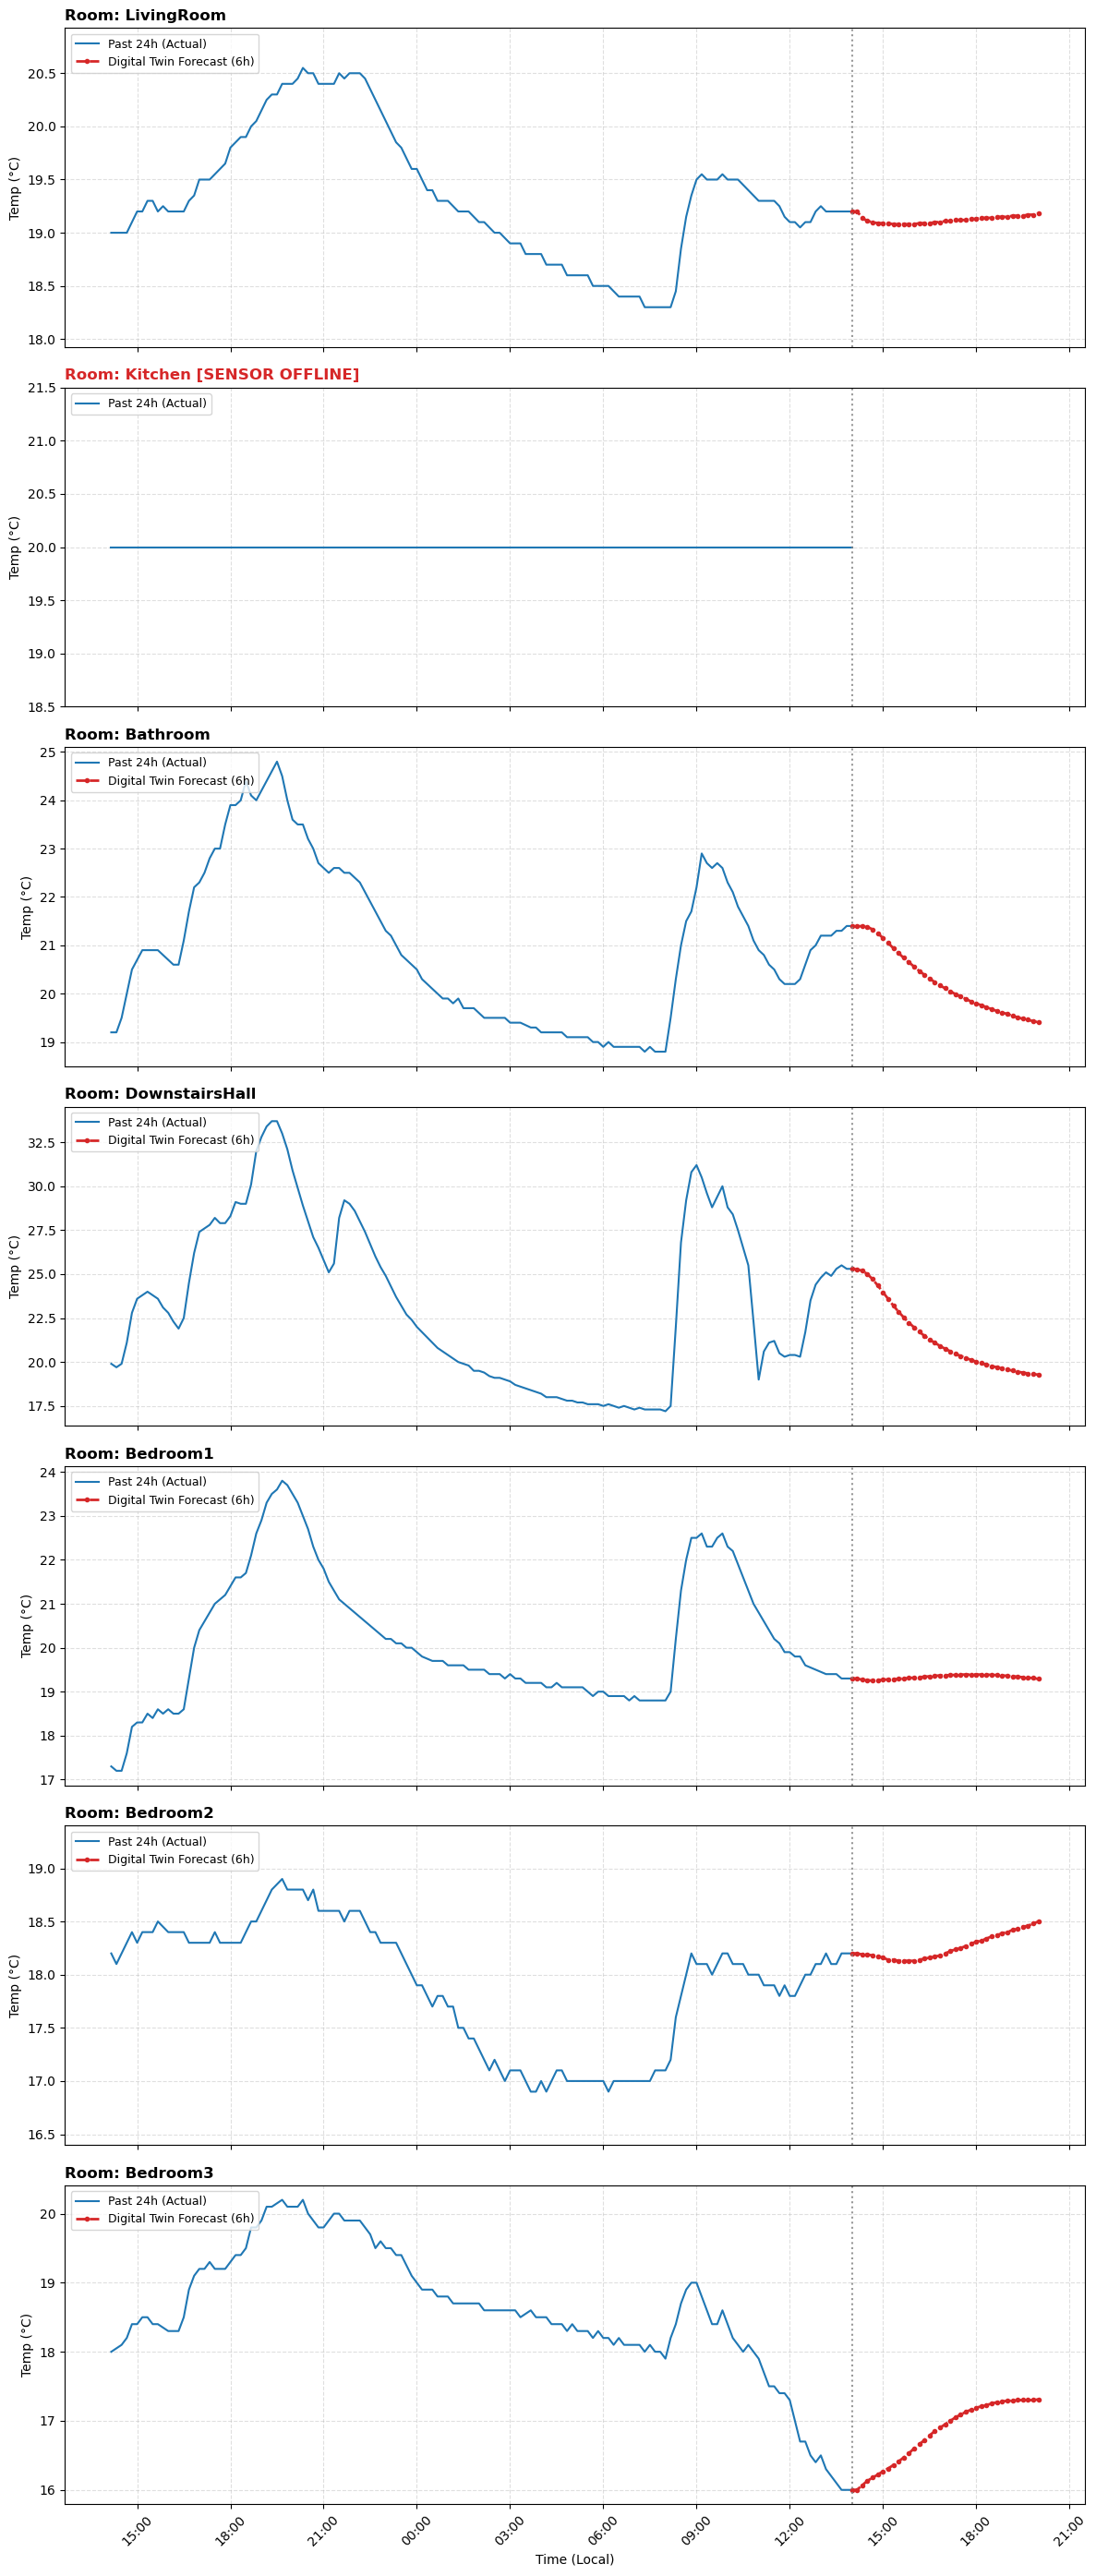

In [4]:
print("\n--- Generating Visualization ---")
# Initialize a temporary predictor just to use the .plot() method
target_rooms = list(final_output["rooms"].keys())
viz_tool = TwinPredictor(model_path='', target_rooms=target_rooms)
viz_tool.plot(df_history, final_output)